<a href="https://colab.research.google.com/github/kinantirizky/Analisis-Deret-Waktu-/blob/main/Tugas_Kelompok_Minggu_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fenniya Angel Lee M0501261094

Husnul Amira M0501251059

Kinanti Rizky Pangestutik M0501251038

**1. IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import boxcox

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

**2. Membaca Data**

In [ ]:
file_path = "/content/inflasi mataram.xlsx"

df = pd.read_excel(file_path)

print("5 data pertama:")
display(df.head())

5 data pertama:


,inflasi,tahun
0,0.04,2001-01-01
1,1.35,2001-02-01
2,0.89,2001-03-01
3,-0.36,2001-04-01
4,1.25,2001-05-01


**3. Pemeriksaan Data**

In [ ]:
print("Ukuran data:", df.shape)

print("\nInformasi data:")
df.info()

print("\nJumlah missing value:")
print(df.isnull().sum())

print("\nJumlah data duplikat:")
print(df.duplicated().sum())

Ukuran data: (300, 2)

Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   inflasi  300 non-null    float64       
 1   tahun    300 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.8 KB

Jumlah missing value:
inflasi    0
tahun      0
dtype: int64

Jumlah data duplikat:
0


**4. Persiapan Analisis Data Deret Waktu**

In [ ]:
df["tahun"] = pd.to_datetime(df["tahun"])

df = df.sort_values("tahun")

ts = df.set_index("tahun")["inflasi"]

print("Periode awal :", ts.index.min())
print("Periode akhir:", ts.index.max())
print("Jumlah data  :", len(ts))

display(ts.head())

Periode awal : 2001-01-01 00:00:00
Periode akhir: 2025-12-01 00:00:00
Jumlah data  : 300


,inflasi
tahun,
2001-01-01,0.04
2001-02-01,1.35
2001-03-01,0.89
2001-04-01,-0.36
2001-05-01,1.25


**5. Plot Deret Waktu**

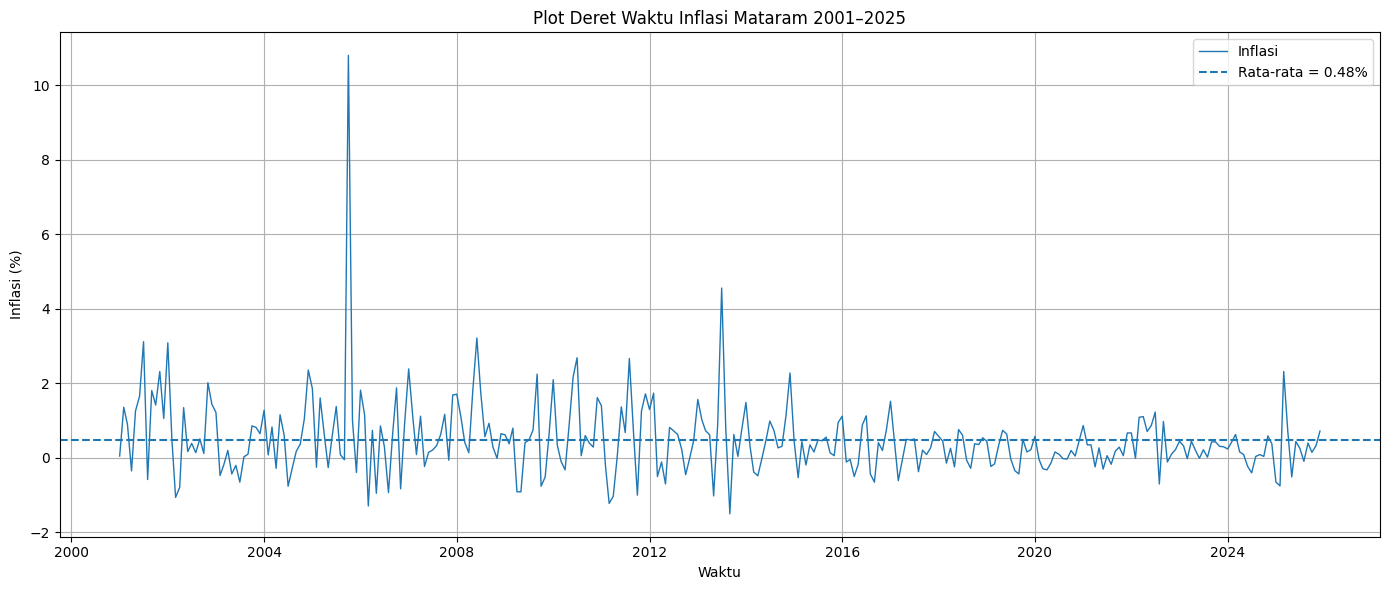

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    ts.index,
    ts.values,
    linewidth=1,
    label="Inflasi"
)

plt.axhline(
    ts.mean(),
    linestyle="--",
    label=f"Rata-rata = {ts.mean():.2f}%"
)

plt.title("Plot Deret Waktu Inflasi Mataram 2001–2025")
plt.xlabel("Waktu")
plt.ylabel("Inflasi (%)")
plt.legend()

plt.tight_layout()
plt.show()


Berdasarkan plot deret waktu di atas, inflasi Kota Mataram terlihat berfluktuasi di sekitar rata-rata 0,48%. Secara visual, deret waktu ini tidak menunjukkan adanya pola tren jangka panjang, sehingga data cenderung stasioner dalam rata-rata. Namun terdapat lonjakan ekstrem pada 2005 (10,80%), serta lonjakan lebih kecil pada 2013 (4,55%). Ketidakkonstanan lebar fluktuasi ini menjadi indikasi bahwa varians data tidak homogen, atau belum stasioner dalam ragam.

**7. Statistik Deskriptif**

In [ ]:
print("Mean     :", ts.mean())
print("Median   :", ts.median())
print("Variance :", ts.var())
print("Std Dev  :", ts.std())
print("Minimum  :", ts.min())
print("Maximum  :", ts.max())

Mean     : 0.4772
Median   : 0.355
Variance : 1.031182769230769
Std Dev  : 1.0154716978974692
Minimum  : -1.51
Maximum  : 10.8


Nilai rata-rata (0,4772) yang lebih besar dari median (0,355) menunjukkan distribusi menceng ke kanan (right-skewed) yang dipicu oleh nilai ekstrem maksimum sebesar 10,8. Selain itu, rentang (range) data antara minimum (-1,51) dan maksimum (10,80) yang sangat lebar dibandingkan dengan simpangan bakunya (1,015) mengonfirmasi adanya outlier signifikan.

**8. Rolling Mean**

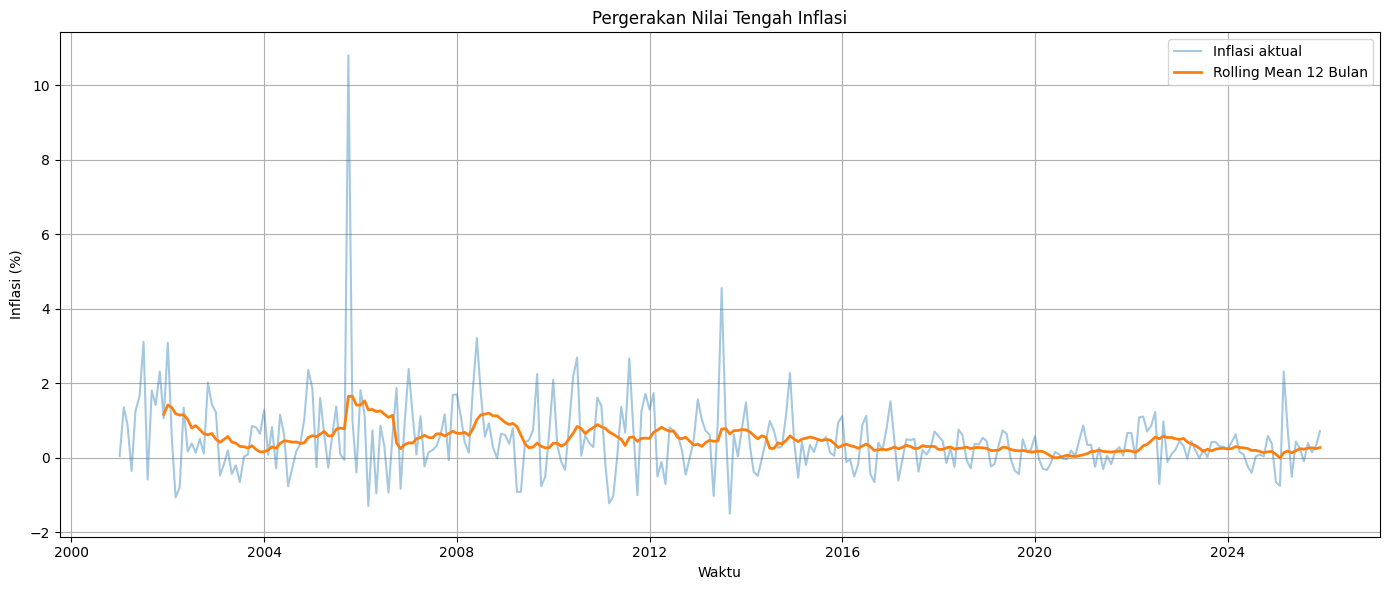

In [ ]:
rolling_mean = ts.rolling(window=12).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    ts,
    alpha=0.4,
    label="Inflasi aktual"
)

plt.plot(
    rolling_mean,
    linewidth=2,
    label="Rolling Mean 12 Bulan"
)

plt.title("Pergerakan Nilai Tengah Inflasi")
plt.xlabel("Waktu")
plt.ylabel("Inflasi (%)")
plt.legend()

plt.tight_layout()
plt.show()

Garis rolling mean (oranye) bergerak relatif stabil di kisaran 0%–1,5% sepanjang periode 2001–2025, jauh lebih halus dibandingkan data aktual (biru) yang sangat fluktuatif. Hal ini menunjukkan bahwa dalam jangka menengah 12 bulan, nilai tengah inflasi Mataram cenderung konsisten tanpa tren naik/turun jangka panjang, memperkuat indikasi bahwa data stasioner dalam rata-rata.

Kenaikan rolling mean yang tampak jelas pada sekitar 2005–2006 merupakan dampak dari lonjakan ekstrem inflasi yang mencapai 10,80%, namun rolling mean cepat kembali turun ke level normal setelah lonjakan tersebut mereda menandakan lonjakan bersifat sementara (shock), bukan perubahan struktural pada rata-rata jangka panjang. Sejak 2016 hingga 2025, rolling mean terlihat semakin mendatar dan berada pada level yang lebih rendah (mendekati 0%), mengindikasikan inflasi Mataram semakin stabil dan terkendali pada dekade terakhir.

**9. Rolling Standar Deviasi**

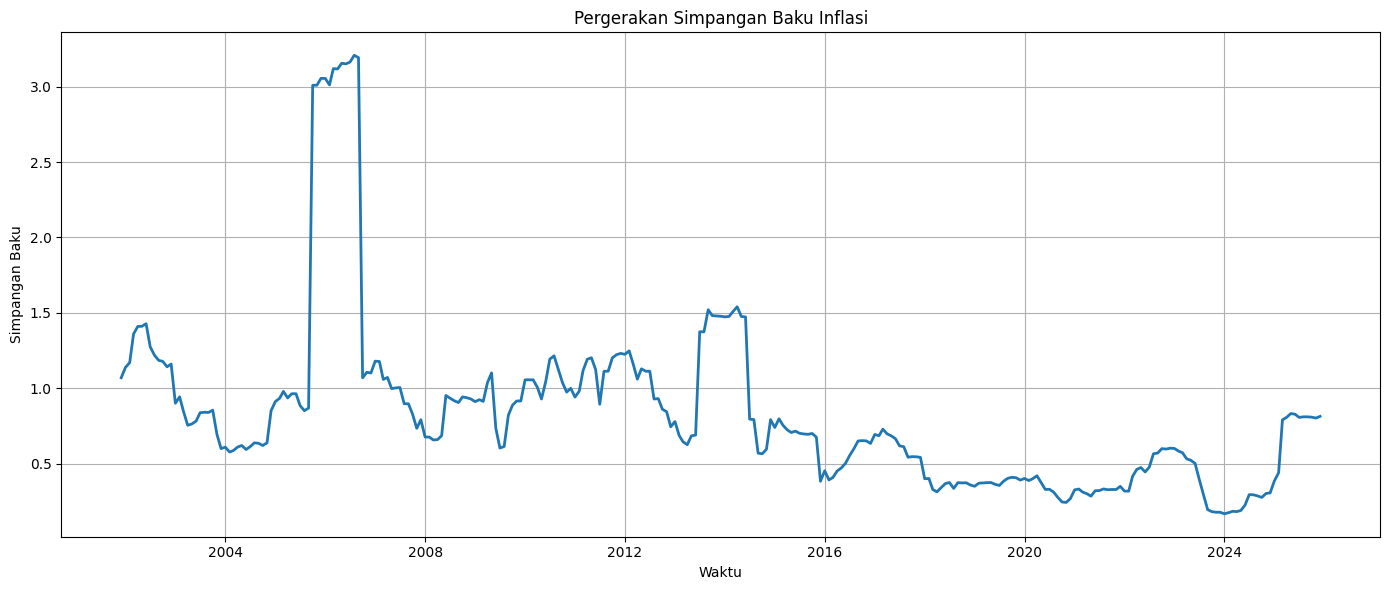

In [ ]:
rolling_std = ts.rolling(window=12).std()

plt.figure(figsize=(14, 6))

plt.plot(
    rolling_std,
    linewidth=2
)

plt.title("Pergerakan Simpangan Baku Inflasi")
plt.xlabel("Waktu")
plt.ylabel("Simpangan Baku")

plt.tight_layout()
plt.show()

Simpangan baku bergerak (rolling std) berfluktuasi cukup lebar, berkisar antara 0,2 hingga 3,2, jauh lebih tidak stabil dibandingkan pola rolling mean. Lonjakan tertinggi terjadi pada periode 2005–2006, mencapai sekitar 3,0–3,2, sebelum turun tajam ke kisaran 1,0 di akhir 2006. Lonjakan kedua yang lebih kecil terlihat pada 2013–2014, dengan simpangan baku mencapai sekitar 1,5.

Pola ini menunjukkan bahwa varians inflasi tidak konstan sepanjang waktu (heteroskedastisitas), sehingga data belum sepenuhnya stasioner dalam ragam. Namun sejak sekitar 2016 hingga 2025, simpangan baku cenderung menurun dan berada pada level yang lebih rendah serta stabil (umumnya di bawah 1,0), mengindikasikan volatilitas inflasi Mataram semakin berkurang pada dekade terakhir dibandingkan periode 2001–2015.

**10. Scatterplot lag 1**

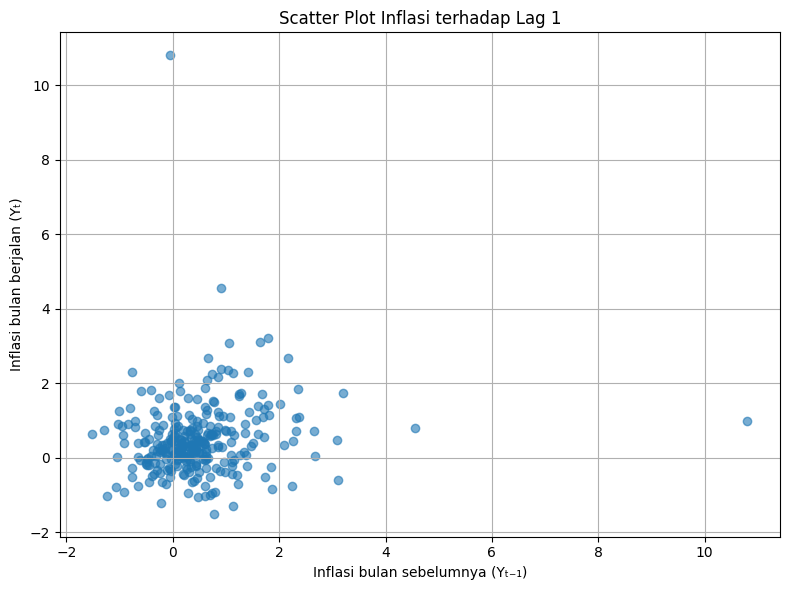

In [ ]:
lag1 = pd.DataFrame({
    "Inflasi_t": ts,
    "Inflasi_t-1": ts.shift(1)
}).dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    lag1["Inflasi_t-1"],
    lag1["Inflasi_t"],
    alpha=0.6
)

plt.xlabel("Inflasi bulan sebelumnya (Yₜ₋₁)")
plt.ylabel("Inflasi bulan berjalan (Yₜ)")
plt.title("Scatter Plot Inflasi terhadap Lag 1")

plt.tight_layout()
plt.show()

Scatter plot antara inflasi bulan berjalan dan inflasi satu bulan sebelumnya menunjukkan titik-titik data tersebar tanpa membentuk pola linear yang jelas, mayoritas terkumpul di sekitar nilai 0–2 pada kedua sumbu. Tidak terlihat arah hubungan yang konsisten (baik naik maupun turun) antara inflasi bulan berjalan dengan inflasi bulan sebelumnya, menunjukkan bahwa hubungan linear antara inflasi saat ini dengan inflasi satu bulan sebelumnya lemah. Terlihat juga satu titik outlier ekstrem pada nilai 10,80% (Oktober 2005) yang terpisah jauh dari kelompok data utama, yang berpotensi menjadi leverage point saat pendugaan parameter model AR/MA nantinya.

**11. Scatterplot lag 12**

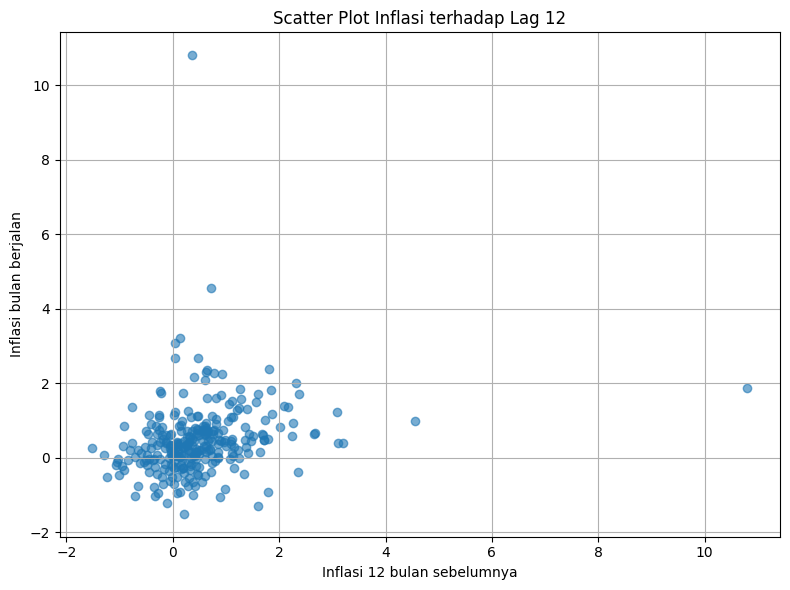

In [ ]:
lag12 = pd.DataFrame({
    "Inflasi_t": ts,
    "Inflasi_t-12": ts.shift(12)
}).dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    lag12["Inflasi_t-12"],
    lag12["Inflasi_t"],
    alpha=0.6
)

plt.xlabel("Inflasi 12 bulan sebelumnya")
plt.ylabel("Inflasi bulan berjalan")
plt.title("Scatter Plot Inflasi terhadap Lag 12")

plt.tight_layout()
plt.show()

Serupa dengan lag 1, sebaran titik pada scatter plot lag 12 juga tidak menunjukkan pola linear yang jelas antara inflasi bulan berjalan dengan inflasi 12 bulan sebelumnya, dengan mayoritas titik terkumpul di sekitar nilai 0–2. Hal ini mengindikasikan bahwa autokorelasi musiman pada Lag 12 tergolong lemah. Titik outlier ekstrem (10,80%) juga tetap terlihat terpisah dari kelompok data utama pada plot ini.

**12. Boxplot**

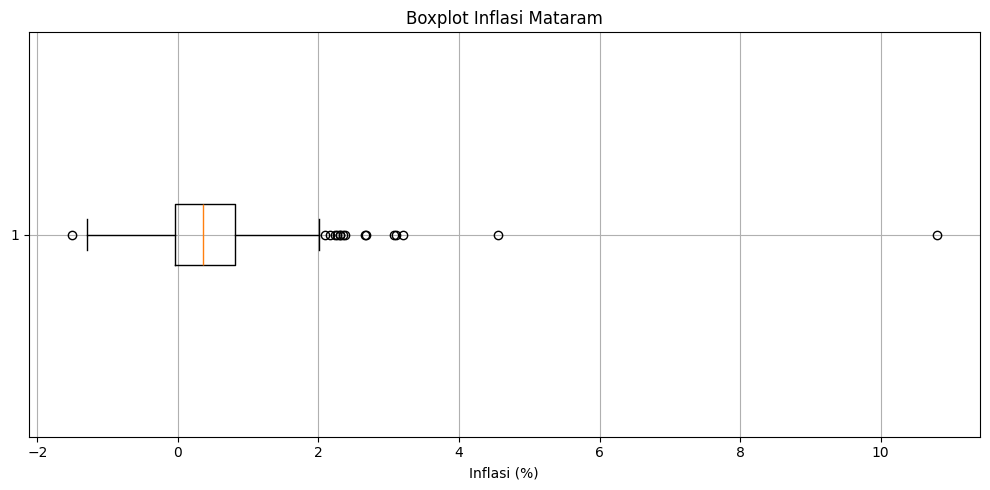

In [ ]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    ts,
    vert=False
)

plt.xlabel("Inflasi (%)")
plt.title("Boxplot Inflasi Mataram")

plt.tight_layout()
plt.show()

Boxplot secara keseluruhan memperlihatkan sebaran data yang memiliki banyak pencilan (outliers) di kedua ekor distribusinya. Sepuluh nilai tertinggi didominasi oleh inflasi Oktober 2005 (10,80%) yang nilainya menjauh signifikan dari data lainnya (nilai tertinggi kedua hanya 4,55%), sementara deflasi terdalam terjadi pada September 2013 (-1,51%).

- melihat data tertinggi dan terendah

In [ ]:
print("10 nilai inflasi tertinggi:")
print(ts.nlargest(10))

print("\n10 nilai inflasi terendah:")
print(ts.nsmallest(10))

10 nilai inflasi tertinggi:
tahun
2005-10-01    10.80
2013-07-01     4.55
2008-06-01     3.21
2001-07-01     3.11
2002-01-01     3.08
2010-07-01     2.68
2011-08-01     2.66
2007-01-01     2.38
2004-12-01     2.35
2001-11-01     2.31
Name: inflasi, dtype: float64

10 nilai inflasi terendah:
tahun
2013-09-01   -1.51
2006-03-01   -1.30
2011-03-01   -1.23
2002-03-01   -1.07
2011-04-01   -1.04
2013-05-01   -1.03
2011-10-01   -1.01
2006-05-01   -0.96
2006-08-01   -0.94
2009-04-01   -0.92
Name: inflasi, dtype: float64


**13. Boxplot berdasarkan bulan**

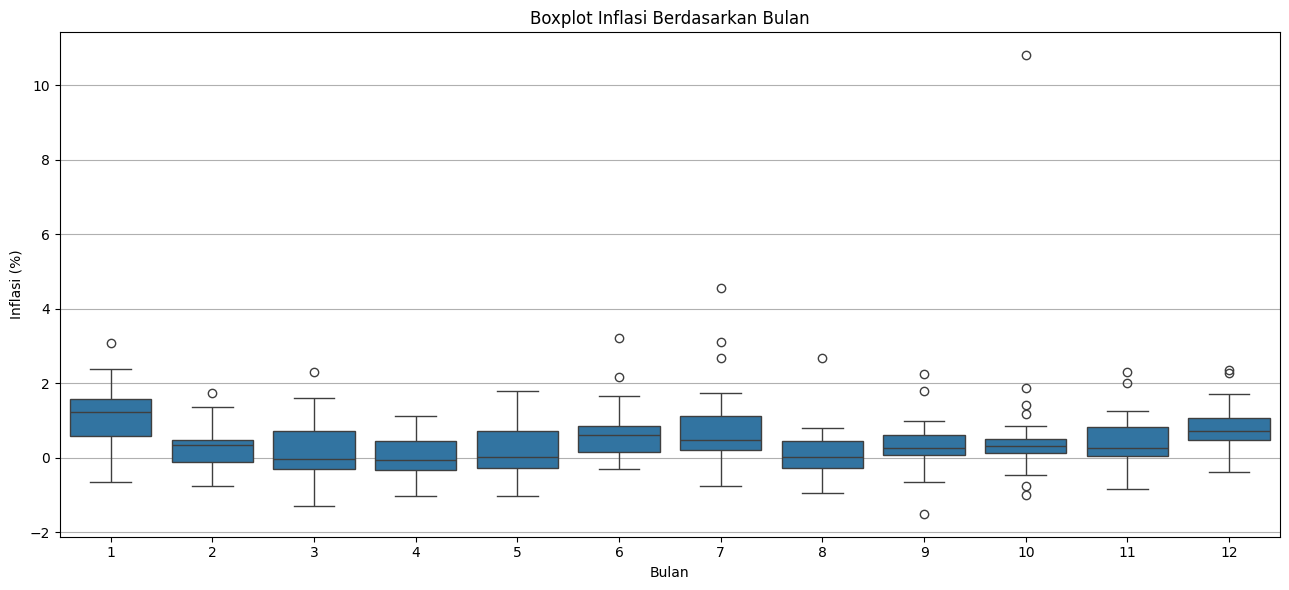

In [ ]:
df["bulan"] = df["tahun"].dt.month

plt.figure(figsize=(13, 6))

sns.boxplot(
    data=df,
    x="bulan",
    y="inflasi"
)

plt.title("Boxplot Inflasi Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Inflasi (%)")

plt.tight_layout()
plt.show()

Median inflasi tertinggi terjadi pada bulan Januari (±1,2%), sementara bulan lainnya berkisar antara 0%–0,7%, mengindikasikan kecenderungan inflasi lebih tinggi di awal tahun (pola musiman). Sebaran data juga bervariasi antar bulan, dengan outlier paling ekstrem terlihat pada bulan Oktober (10,80%) dan September (-1,51%). Lebar kotak (Interquartile Range) yang bervariasi antar bulan juga kembali menegaskan adanya heteroskedastisitas sepanjang tahun.

**14. Dekomposisi STL**

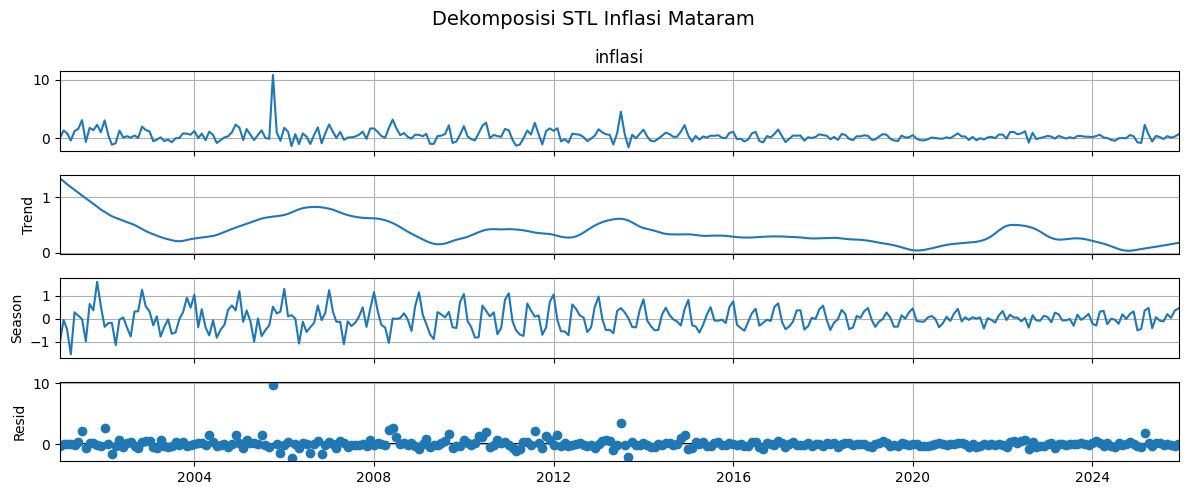

In [ ]:
stl = STL(
    ts,
    period=12,
    robust=True
)

hasil_stl = stl.fit()

hasil_stl.plot()

plt.suptitle(
    "Dekomposisi STL Inflasi Mataram",
    fontsize=14
)

plt.tight_layout()
plt.show()

Trend: Bergerak pada rentang yang sempit tanpa pola naik/turun jangka panjang, menegaskan bahwa deret waktu ini tidak memiliki tren kuat dan stasioner dalam rata-rata.

Seasonal: Menunjukkan pola bulanan yang berulang secara konsisten setiap tahunnyan, mengonfirmasi adanya musiman bulanan.

Residual (Sisaan): Sebagian besar sisaan berfluktuasi stabil di sekitar angka 0, kecuali satu lonjakan residu ekstrem pada 2005. Hal ini membuktikan bahwa lonjakan tersebut murni merupakan guncangan (shock) eksternal yang tidak bisa dijelaskan oleh pola tren maupun musiman, dan menjadi pemicu utama ketidakstabilan varians data.

**15. Uji Stasioneritas**

In [ ]:
adf_asli = adfuller(
    ts.dropna(),
    autolag="AIC"
)

print("ADF Statistic :", adf_asli[0])
print("p-value       :", adf_asli[1])
print("Lag digunakan :", adf_asli[2])
print("Observasi      :", adf_asli[3])

print("\nCritical Values:")

for key, value in adf_asli[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.208734307580341
p-value       : 0.0006368243610441704
Lag digunakan : 11
Observasi      : 288

Critical Values:
1%: -3.453261605529366
5%: -2.87162848654246
10%: -2.5721455328896603


Hipotesis :

$H_0$ menyatakan deret tidak stasioner ($H_0: \gamma = 0$)

$H_1$ menyatakan deret stasioner. ($H_1: \gamma < 0$)

Kriteria keputusan: tolak $H_0$ jika p-value < 0,05  ($\alpha$) atau jika nilai ADF Statistic < Critical Value..

Berdasarkan hasil uji ADF, diperoleh nilai ADF Statistic sebesar -4,21, yang lebih kecil dibandingkan seluruh critical value (1%: -3,45; 5%: -2,87; 10%:-2,57), dengan p-value sebesar 0,00064, yang mana bernilai jauh lebih kecil dari 0,05. Dengan demikian, $H_0$ ditolak, yang menyimpulkan bahwa data inflasi Kota Mataram sudah stasioner dalam rata-rata.

**16. ACF**

<Figure size 1200x500 with 0 Axes>

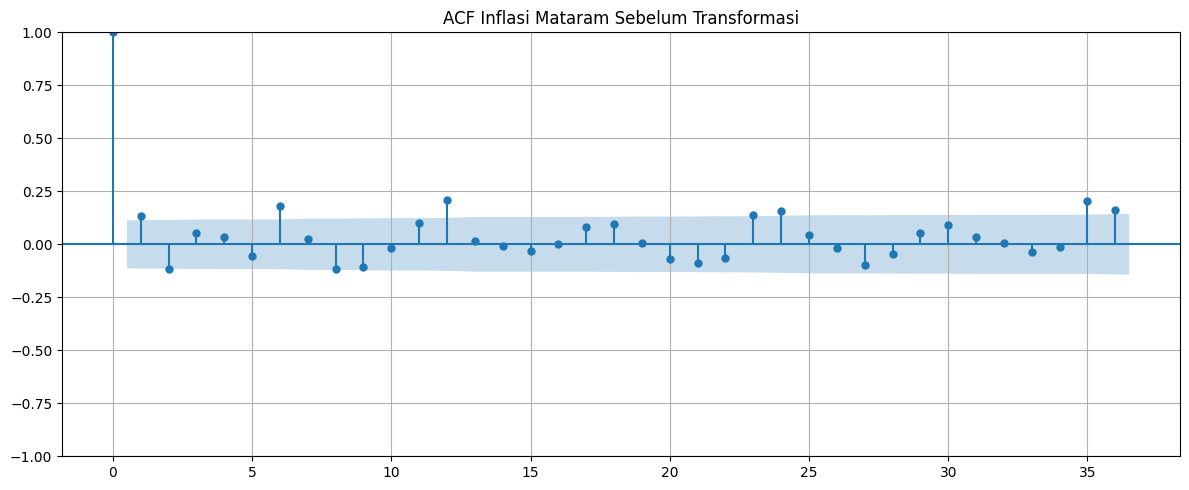

In [ ]:
plt.figure(figsize=(12, 5))

plot_acf(
    ts.dropna(),
    lags=36,
    alpha=0.05
)

plt.title("ACF Inflasi Mataram Sebelum Transformasi")

plt.tight_layout()
plt.show()

Plot ACF menunjukkan bahwa hampir seluruh nilai autokorelasi pada lag 1 hingga 36 berada di dalam pita signifikansi (area biru), yang berarti secara umum tidak terdapat autokorelasi yang kuat antar-observasi. Pola ini konsisten dengan sifat deret yang sudah stasioner, mendekati karakteristik white noise.

Meski demikian, terdapat beberapa lag yang sedikit keluar dari pita signifikansi, terutama pada lag 12 (dan sedikit terlihat pada lag 6 serta lag 35), yang mengindikasikan adanya jejak pola musiman tahunan (periode 12 bulan) pada data inflasi, meskipun kekuatannya relatif lemah dan tidak dominan.

**17. PACF**

<Figure size 1200x500 with 0 Axes>

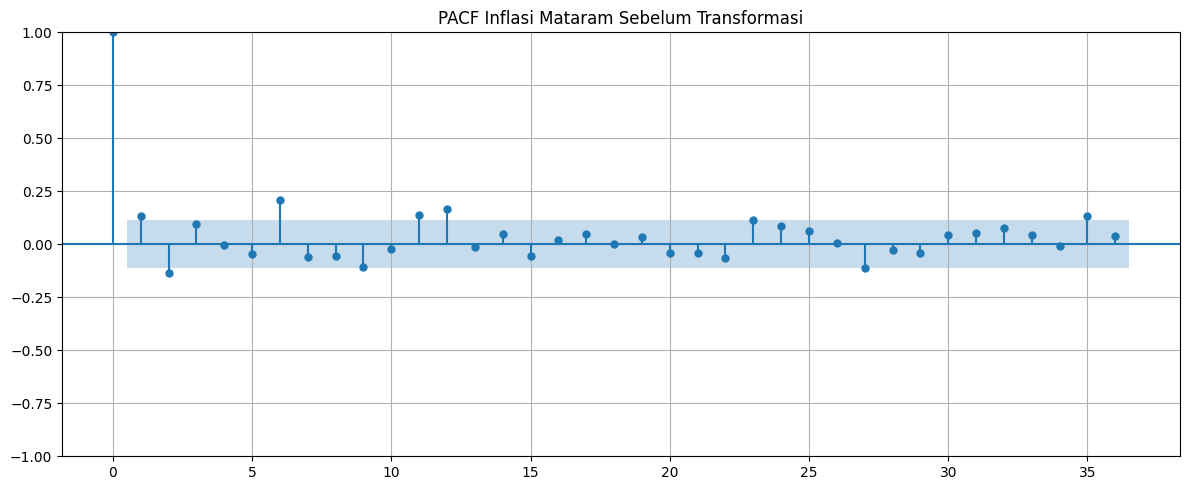

In [ ]:
plt.figure(figsize=(12, 5))

plot_pacf(
    ts.dropna(),
    lags=36,
    alpha=0.05,
    method="ywm"
)

plt.title("PACF Inflasi Mataram Sebelum Transformasi")

plt.tight_layout()
plt.show()

Plot PACF menunjukkan sebagian besar nilai autokorelasi parsial pada lag 1–36 berada di dalam pita signifikansi (area biru), menandakan tidak ada korelasi parsial yang kuat antar-observasi setelah lag pertama. Beberapa lag sedikit keluar dari pita signifikansi, seperti lag 2, 6, 11, 12, dan 27, mengindikasikan adanya jejak keterkaitan pada lag-lag tersebut, namun kekuatannya relatif lemah dan tidak dominan. Pola ini turut mendukung indikasi bahwa data inflasi Mataram sudah stasioner.

**18. Boxcox**

In [ ]:
# Konstanta shift agar seluruh data bernilai positif
shift = abs(ts.min()) + 0.01

ts_positive = ts + shift

print("Konstanta shift :", shift)
print("Nilai minimum setelah shift :", ts_positive.min())

Konstanta shift : 1.52
Nilai minimum setelah shift : 0.010000000000000009


- transformasi Boxcox

Hipotesis Uji Box-Cox:

$H_0: \lambda = 1$ (Data sudah stasioner dalam ragam, tidak memerlukan transformasi)

$H_1: \lambda \neq 1$ (Data belum stasioner dalam ragam, memerlukan transformasi sebesar $\lambda$ optimum)

Kriteria Keputusan: Tolak $H_0$ jika rentang selang kepercayaan (Confidence Interval / CI) 95% untuk nilai $\lambda$ tidak memuat angka 1.

Rumus Transformasi Box-Cox:

$$y_t^{(\lambda)} = \begin{cases} \frac{y_t^\lambda - 1}{\lambda}, & \text{jika } \lambda \neq 0 \\ \ln(y_t), & \text{jika } \lambda = 0 \end{cases}$$

In [ ]:
# Transformasi Box-Cox
ts_boxcox_array, lambda_boxcox = boxcox(ts_positive)

print("Lambda Box-Cox :", lambda_boxcox)

Lambda Box-Cox : 0.40341275241742397


In [ ]:
from scipy.stats import boxcox

# Transformasi Box-Cox sekaligus mencari lambda dan 95% CI
ts_boxcox_array, lambda_opt, ci = boxcox(
    ts_positive,
    alpha=0.05
)

print("Lambda optimal :", lambda_opt)
print("95% CI Lambda  :", ci)

Lambda optimal : 0.40341275241742397
95% CI Lambda  : (0.3036175174434397, 0.5096877698307049)


Hasil optimasi Box-Cox menghasilkan penduga titik $\lambda$ sebesar $0,403$ dengan rentang selang kepercayaan 95% berada di antara $(0,303, 0,509)$. CI lambda tidak mencakup 1 sehingga dapat diambil kesimpulan yaitu tolak $H_0$, yaitu data tidak memiliki bukti kuat bahwa sudah stasioner dalam ragam (terdapat masalah heteroskedastisitas), sehingga diperlukan transformasi. Nilai lambda optimal ≈ 0.4 berada di antara transformasi akar kuadrat (λ=0.5) dan logaritma (λ=0), digunakan untuk menstabilkan varians (mengurangi heteroskedastisitas).

- transformasi Boxcox menggunakan lamda (manual)

In [ ]:
lambda_opt = 0.40341275241742397

ts_boxcox = ((ts_positive ** lambda_opt) - 1) / lambda_opt

# Jadikan Series
ts_boxcox = pd.Series(
    ts_boxcox,
    index=ts.index,
    name="inflasi_boxcox"
)

print("Lambda yang digunakan :", lambda_opt)
print("\n5 data pertama setelah Box-Cox:")
print(ts_boxcox.head())

Lambda yang digunakan : 0.40341275241742397

5 data pertama setelah Box-Cox:
tahun
2001-01-01    0.487068
2001-02-01    1.314000
2001-03-01    1.055917
2001-04-01    0.152953
2001-05-01    1.260123
Name: inflasi_boxcox, dtype: float64


In [ ]:
ts_boxcox = pd.Series(
    ts_boxcox_array,
    index=ts.index,
    name="inflasi_boxcox"
)

display(ts_boxcox.head())

,inflasi_boxcox
tahun,
2001-01-01,0.487068
2001-02-01,1.314000
2001-03-01,1.055917
2001-04-01,0.152953
2001-05-01,1.260123


**19. Perbandingan sebelum dan sesudah boxcox**

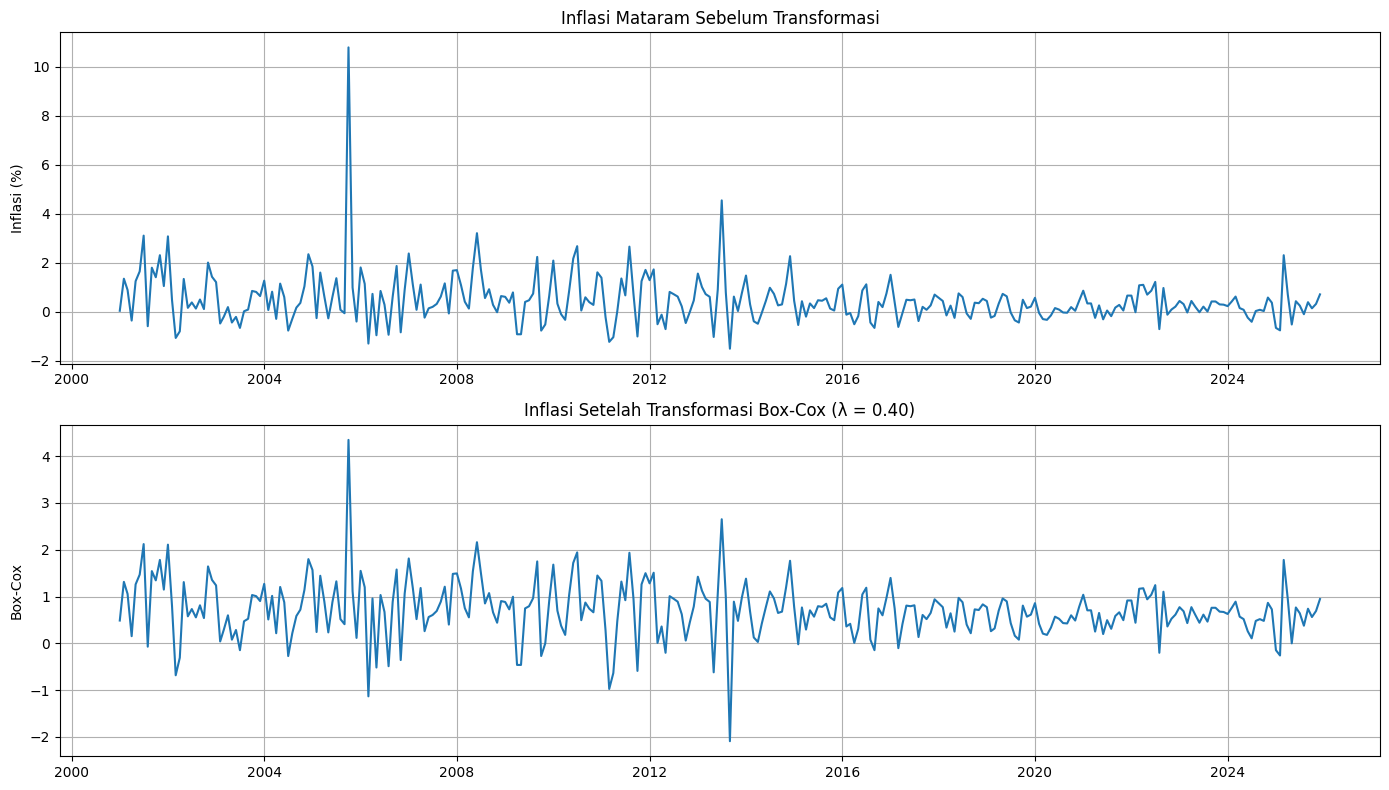

In [ ]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8)
)

# Data asli
axes[0].plot(ts)
axes[0].set_title("Inflasi Mataram Sebelum Transformasi")
axes[0].set_ylabel("Inflasi (%)")

# Data Box-Cox
axes[1].plot(ts_boxcox)
axes[1].set_title(
    f"Inflasi Setelah Transformasi Box-Cox (λ = {lambda_boxcox:.2f})"
)
axes[1].set_ylabel("Box-Cox")

plt.tight_layout()
plt.show()

Secara visual, pola pergerakan inflasi sebelum dan sesudah transformasi Box-Cox (λ = 0,40) terlihat serupa, namun skala fluktuasinya berbeda. Pada data sebelum transformasi, lonjakan ekstrem tahun 2005 mencapai 10,80%, jauh di atas fluktuasi normal yang berkisar -1% hingga 2%. Setelah transformasi Box-Cox, lonjakan tersebut mengecil menjadi sekitar 4,3, sehingga rentang antara nilai ekstrem dan nilai normal menjadi lebih proporsional, menandakan varians data lebih stabil.

Selain itu, pada data hasil transformasi terlihat nilai ekstrem rendah yang lebih menonjol di sekitar 2013 (mencapai sekitar -2,1), yang pada data asli tidak terlalu ekstrem (-1,5). Hal ini wajar terjadi karena Box-Cox bersifat non-linear transformasi ini menekan nilai-nilai besar secara proporsional lebih kuat dibanding nilai kecil, sehingga dapat sedikit mengubah posisi relatif antar titik data ekstrem.

Secara keseluruhan, transformasi Box-Cox berhasil meredam dominasi outlier ekstrem tahun 2005 dan membuat fluktuasi data menjadi lebih merata sepanjang periode pengamatan, sejalan dengan tujuannya untuk menstabilkan varians data inflasi.

**20. Perbandingan  Rolling Standar Deviasi**

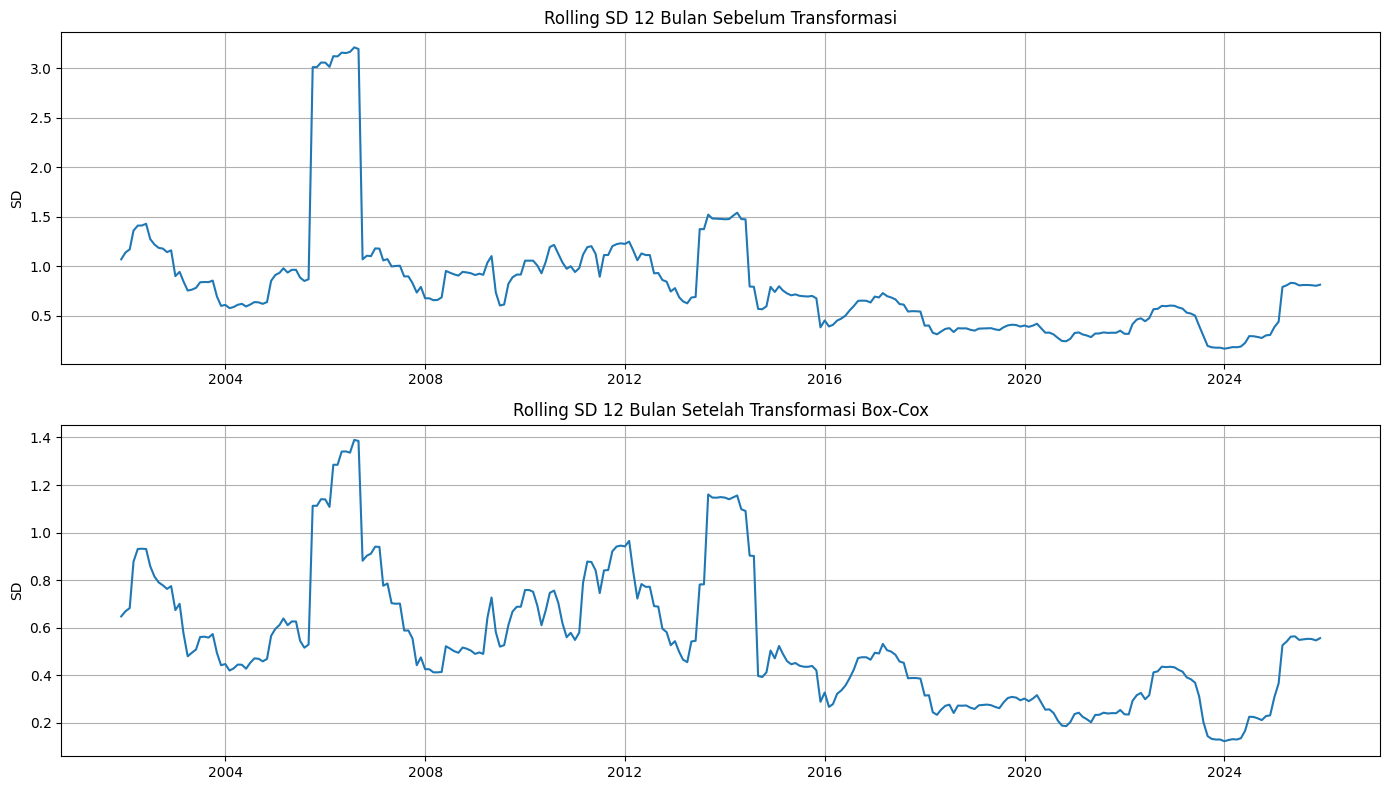

In [ ]:
rolling_sd_asli = ts.rolling(12).std()
rolling_sd_boxcox = ts_boxcox.rolling(12).std()

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8)
)

axes[0].plot(rolling_sd_asli)
axes[0].set_title(
    "Rolling SD 12 Bulan Sebelum Transformasi"
)
axes[0].set_ylabel("SD")

axes[1].plot(rolling_sd_boxcox)
axes[1].set_title(
    "Rolling SD 12 Bulan Setelah Transformasi Box-Cox"
)
axes[1].set_ylabel("SD")

plt.tight_layout()
plt.show()

Pola rolling SD sebelum dan sesudah transformasi Box-Cox terlihat serupa, dengan lonjakan tertinggi tetap terjadi pada periode 2005–2006 dan 2013–2014. Namun, skala fluktuasinya jauh lebih kecil setelah transformasi lonjakan tertinggi yang semula mencapai sekitar 3,2 turun menjadi sekitar 1,4. Hal ini menunjukkan bahwa transformasi Box-Cox berhasil menstabilkan varians data, meskipun pola periode volatilitas tinggi dan rendah pada data tetap konsisten dengan data aslinya.

**21. Perbandingan varians dan standar daviasi**

In [ ]:
print("Ragam sebelum Box-Cox :", ts.var())
print("Ragam setelah Box-Cox :", ts_boxcox.var())

print("\nSD sebelum Box-Cox :", ts.std())
print("SD setelah Box-Cox :", ts_boxcox.std())

Ragam sebelum Box-Cox : 1.031182769230769
Ragam setelah Box-Cox : 0.3653143211505495

SD sebelum Box-Cox : 1.0154716978974692
SD setelah Box-Cox : 0.6044123767350811


Efektivitas transformasi Box-Cox dalam mengatasi heteroskedastisitas dibuktikan secara kuantitatif melalui penurunan metrik penyebaran data. Varians global menurun drastis dari 1,031 menjadi 0,365, dan standar deviasi menurun dari 1,015 menjadi 0,604 setelah transformasi Box-Cox. Penurunan sebesar ±65% ini menunjukkan bahwa transformasi Box-Cox berhasil menstabilkan varians data inflasi Kota Mataram.

22. Uji ADF setelah Boxcox

In [ ]:
adf_boxcox = adfuller(
    ts_boxcox.dropna(),
    autolag="AIC"
)

print("ADF Statistic :", adf_boxcox[0])
print("p-value       :", adf_boxcox[1])
print("Lag digunakan :", adf_boxcox[2])
print("Observasi     :", adf_boxcox[3])

print("\nCritical Values:")

for key, value in adf_boxcox[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.793488333716673
p-value       : 5.5967508776300544e-05
Lag digunakan : 11
Observasi     : 288

Critical Values:
1%: -3.453261605529366
5%: -2.87162848654246
10%: -2.5721455328896603


Uji akar satuan yang pertama adalah uji akar-satuan Dickey Fuller (ADF test). Hipotesis yang digunakan dalam uji ADF adalah

$H_0:$ menyatakan deret tidak stasioner ($H_0: \gamma = 0$).

$H_1:$ menyatakan deret stasioner ($H_1: \gamma < 0$).

Kriteria keputusan: tolak $H_0$ jika p-value < 0,05.

Berdasarkan hasil uji ADF setelah transformasi Box-Cox, diperoleh nilai ADF Statistic sebesar -4,79, lebih negatif dibandingkan seluruh critical value (1%: -3,45; 5%: -2,87; 10%: -2,57), dengan p-value sebesar 0,000056. Karena p-value < 0,05, maka H0 ditolak, sehingga data inflasi Kota Mataram tetap stasioner setelah transformasi Box-Cox.

Dibandingkan hasil ADF sebelum transformasi (ADF Statistic: -4,21; p-value: 0,00064), nilai ADF Statistic setelah Box-Cox menjadi lebih negatif dan p-value semakin kecil, menunjukkan bahwa bukti penolakan $H_0$ menjadi semakin kuat yang berarti bukti stasioneritas data semakin kuat setelah varians data distabilkan melalui transformasi Box-Cox. Hal ini menegaskan bahwa penstabilan ragam melalui Box-Cox turut memperjelas kestasioneran data dalam rata-rata, sehingga deret waktu ini sudah sepenuhnya stasioner dan siap untuk tahapan pemodelan.

**23. ACF setelah Boxcox**

<Figure size 1200x500 with 0 Axes>

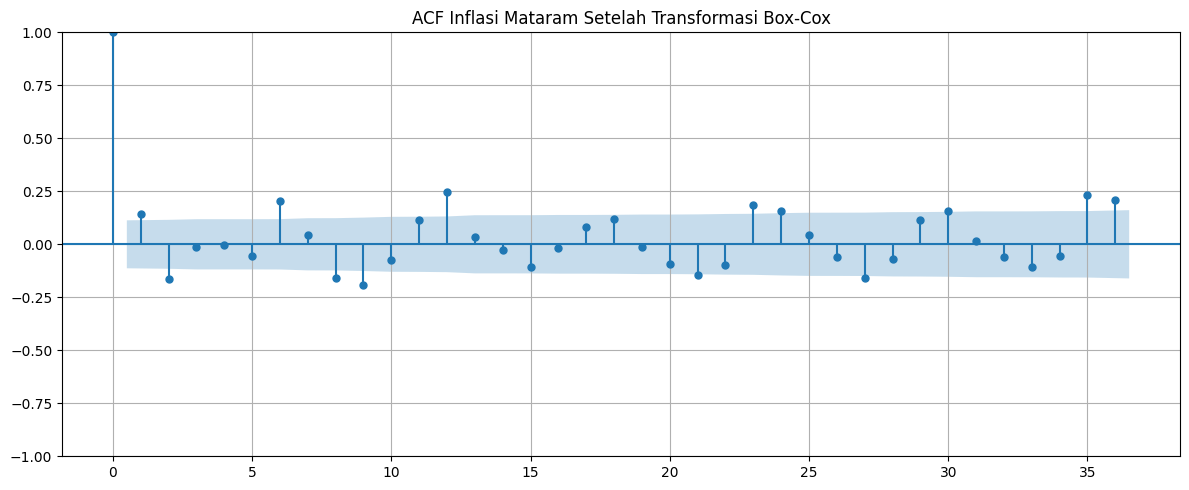

In [ ]:
plt.figure(figsize=(12, 5))

plot_acf(
    ts_boxcox.dropna(),
    lags=36,
    alpha=0.05
)

plt.title("ACF Inflasi Mataram Setelah Transformasi Box-Cox")

plt.tight_layout()
plt.show()

Pada plot ACF, mirip dengan pola sebelum transformasi, sebagian besar lag berada di dalam pita signifikansi, kecuali beberapa lag yang sedikit keluar seperti lag 1, 2, 6, 9, dan 12, mengindikasikan adanya jejak korelasi lemah, termasuk pola musiman pada lag 12.

**24. PACF seletalh Boxcox**

<Figure size 1200x500 with 0 Axes>

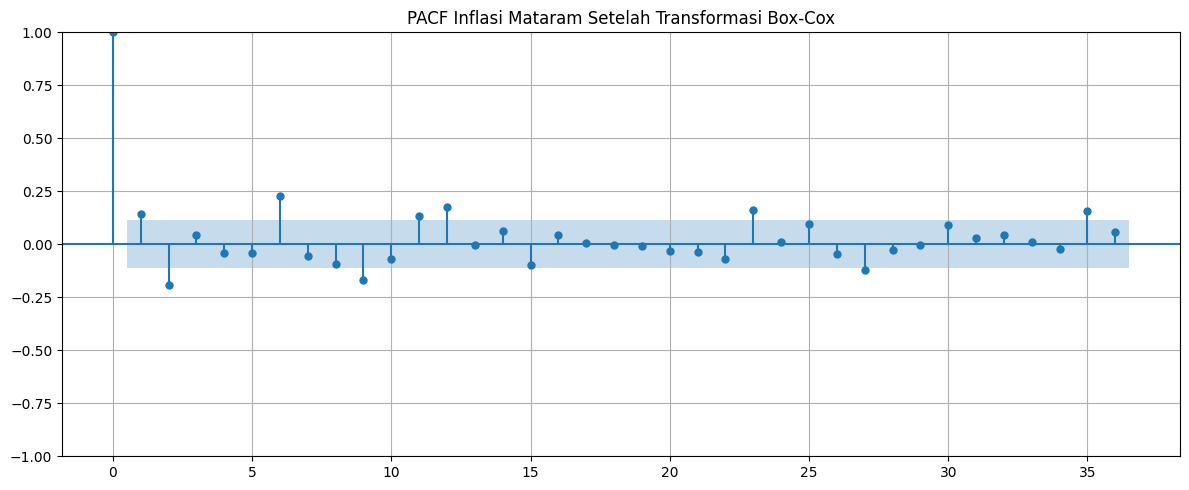

In [ ]:
plt.figure(figsize=(12, 5))

plot_pacf(
    ts_boxcox.dropna(),
    lags=36,
    alpha=0.05,
    method="ywm"
)

plt.title("PACF Inflasi Mataram Setelah Transformasi Box-Cox")

plt.tight_layout()
plt.show()

Pada plot PACF, pola serupa terlihat dengan beberapa lag yang sedikit keluar dari pita signifikansi, terutama lag 1, 2, 6, dan 12, menunjukkan kemungkinan keterkaitan orde AR rendah serta jejak musiman pada lag 12.

Secara umum, pola ACF dan PACF setelah transformasi Box-Cox relatif mirip dengan pola sebelum transformasi, menandakan bahwa struktur autokorelasi data tidak berubah signifikan transformasi Box-Cox berperan menstabilkan varians untuk mengatasi heteroskedastisitas dan meredam pencilan, bukan mengubah struktur ketergantungan antar-lag. Hasil ini mengonfirmasi bahwa data sudah stasioner secara rata-rata dan ragam, serta dapat dijadikan dasar untuk  tahap identifikasi parameter $p$ dan $q$ untuk pemodelan ARMA/ARIMA.

**Pertanyaan**

Jika deret tidak stasioner dalam nilaitengah dan ragam, bagaimana urutan penanganan masalah ketidakstasioneran ini? Apakah differencing dahulu lalu transformasi Boxcox atau transformasi Boxcox dahulu lalu differencing?

Jika suatu deret waktu tidak stasioner dalam nilai tengah maupun ragam, urutan penanganan yang benar adalah melakukan transformasi Box-Cox (menstabilkan ragam) terlebih dahulu, baru kemudian melakukan differencing (menstabilkan nilai tengah). Hal ini dikarenakan proses differencing dapat menghasilkan nilai negatif ketika observasi saat ini lebih rendah dari sebelumnya, dan menghilangkan informasi level data asli sehingga membuat perhitungan transformasi non-linear seperti logaritma atau Box-Cox menjadi tidak valid serta kehilangan maknanya.

Namun, pada kasus inflasi mataram ini, hasil uji ADF sebelum transformasi (p-value = 0,00064) maupun sesudah transformasi (p-value = 0,000056) sama-sama sudah signifikan, artinya data inflasi Mataram sejak awal sudah stasioner dalam nilai tengah. Oleh karena itu, tahapan differencing tidak diperlukan pada kasus deret waktu ini. Dalam hal ini cukup dilakukan transformasi Box-Cox untuk mengatasi masalah heteroskedastisitas atau ketidakstasioneran ragam yang disebabkan oleh outlier ekstrem (terutama lonjakan Oktober 2005).